# S-DoT 4,310만 건 센서 데이터로 본 서울의 기후 경향성
2020.04 ~ 2026.02 | 서울시 25개 자치구 | 실시간 IoT 센서 측정

In [1]:
# ============================================================
# 1단계: 필요한 라이브러리 불러오기 (Import)
# ============================================================
# 라이브러리 = 다른 개발자들이 미리 만들어둔 코드 모음
# import = "이 라이브러리를 내 코드에서 쓰겠다"는 선언

import pandas as pd                # pandas: 엑셀처럼 표(DataFrame) 형태로 데이터를 다루는 라이브러리
                                   # pd는 별명(alias) - 매번 pandas 대신 pd로 짧게 쓰려고
import matplotlib.pyplot as plt    # matplotlib: 차트/그래프를 그리는 라이브러리
                                   # pyplot은 그 중 그래프 그리기 기능 모음
import mariadb                     # mariadb: MariaDB 데이터베이스에 접속하는 라이브러리
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨기기 (분석에 영향 없는 경고들이 출력되면 지저분해서)

# ============================================================
# 한글 폰트 설정 (차트에서 한글이 깨지지 않도록)
# ============================================================
# plt.rcParams = matplotlib의 전역 설정을 바꾸는 딕셔너리
plt.rcParams['font.family'] = 'Malgun Gothic'    # 폰트를 '맑은 고딕'으로 설정
plt.rcParams['axes.unicode_minus'] = False       # 마이너스(-) 기호가 □로 깨지는 것 방지
plt.rcParams['figure.dpi'] = 120                 # DPI = 해상도. 숫자가 클수록 선명함

# ============================================================
# MariaDB 데이터베이스 연결
# ============================================================
# 데이터베이스 = 대용량 데이터를 저장하고 빠르게 검색할 수 있는 저장소
# connect() = 데이터베이스에 접속하는 함수
conn = mariadb.connect(
    host='localhost',       # 접속할 서버 주소 (localhost = 내 컴퓨터)
    user='root',            # DB 사용자 이름
    password='00000',       # DB 비밀번호
    database='sdot_db'      # 사용할 데이터베이스 이름 (S-DoT 데이터가 들어있음)
)
print('DB 연결 성공')       # 연결 성공하면 메시지 출력

# ============================================================
# SQL 실행 편의 함수 정의
# ============================================================
# 함수(function) = 자주 쓰는 코드를 묶어서 이름을 붙인 것
# def = "함수를 정의(define)하겠다"
def query(sql):
    """
    SQL 쿼리를 실행하고 결과를 DataFrame으로 반환하는 함수
    
    매개변수:
        sql: 실행할 SQL 문자열 (예: "SELECT * FROM 테이블명")
    반환값:
        pandas DataFrame (표 형태의 데이터)
    
    사용 예시:
        df = query("SELECT * FROM sdot_nature_all LIMIT 10")
    """
    return pd.read_sql(sql, conn)  # pd.read_sql(): SQL 실행 결과를 DataFrame으로 변환
    # 이 함수 덕분에 매번 pd.read_sql(sql, conn) 대신 query(sql)로 짧게 쓸 수 있음

DB 연결 성공


## 1. 데이터 개요 파악

In [2]:
# ============================================================
# 데이터 개요 파악: "우리가 얼마나 많은 데이터를 가지고 있나?"
# ============================================================

# [1] 전체 데이터 건수 조회
# COUNT(*) = 테이블의 모든 행(row) 개수를 세는 SQL 함수
# as cnt = 결과 컬럼에 'cnt'라는 별명을 붙임
total = query('SELECT COUNT(*) as cnt FROM sdot_nature_all')

# [2] 데이터의 시작일과 마지막일 조회
# MIN() = 최솟값 (가장 오래된 날짜)
# MAX() = 최댓값 (가장 최근 날짜)
date_range = query('SELECT MIN(등록일시) as earliest, MAX(등록일시) as latest FROM sdot_nature_all')

# [3] 결과 출력
# .iloc[0] = DataFrame에서 첫 번째 행의 값을 꺼내는 방법
#            iloc = "integer location"의 약자, 숫자 인덱스로 접근
# f"..." = f-string, 문자열 안에 {변수}를 넣어서 값을 출력하는 방법
# :, = 천 단위마다 콤마(,)를 넣는 포맷 (43106796 → 43,106,796)
print(f"총 데이터 건수: {total['cnt'].iloc[0]:,}건")
print(f"데이터 기간: {date_range['earliest'].iloc[0]} ~ {date_range['latest'].iloc[0]}")

# ★ 발표 포인트: "4,310만 건이라는 대용량 데이터를 분석했습니다"

총 데이터 건수: 43,106,782건
데이터 기간: 2020-04-01 01:00:00 ~ 2026-01-18 23:08:00


---
## 2. 연도별 평균 온도 추이

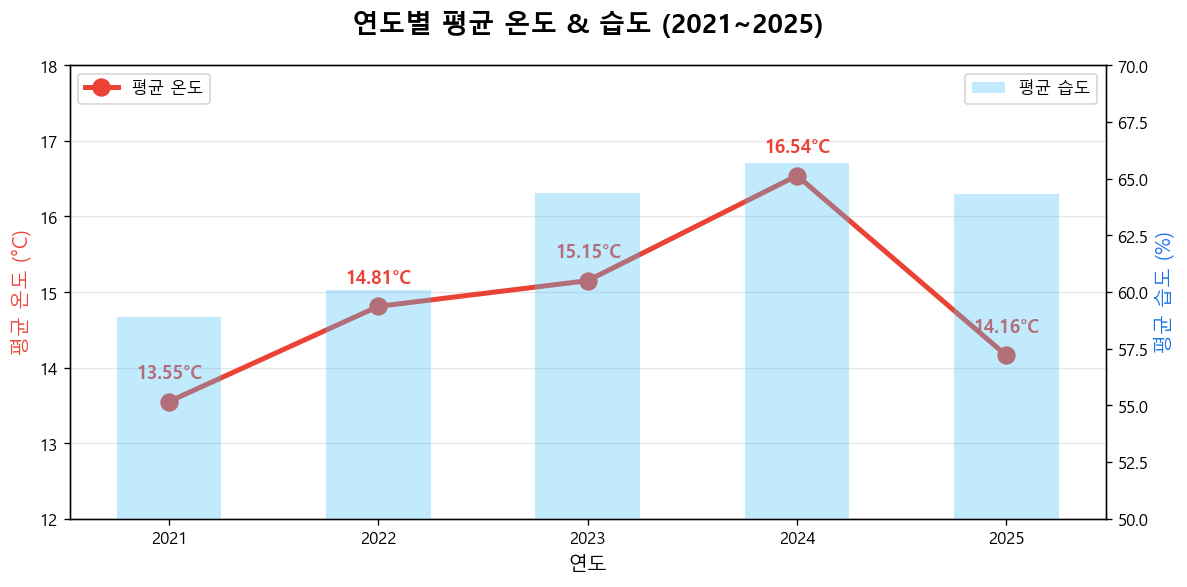


** 2024년이 완전 연도 중 최고 온도(16.54°C) 기록
** 습도도 2023년부터 64% 이상으로 상승 추세


In [3]:
# ============================================================
# 연도별 평균 온도 & 습도 추이 분석
# 목적: "서울이 점점 더워지고 있는가?"를 연도별로 확인
# ============================================================

# [1] SQL로 연도별 평균 데이터 조회
# """ """ = 여러 줄 문자열 (긴 SQL을 보기 좋게 작성)
df_yearly = query("""
SELECT YEAR(등록일시) as year,                    -- YEAR(): 날짜에서 연도만 추출 (2024-08-15 → 2024)
       ROUND(AVG(온도_평균), 2) as avg_temp,      -- AVG(): 평균값 계산, ROUND(값, 2): 소수점 2자리로 반올림
       ROUND(AVG(습도_평균), 2) as avg_humid,     -- 습도 평균
       COUNT(*) as cnt                            -- 해당 연도의 데이터 건수
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type')           -- WHERE: 조건 필터링. 빈 값이나 잘못된 값 제외
  AND 자치구 NOT LIKE '%"%'                       -- LIKE '%"%': 따옴표가 포함된 비정상 데이터 제외
GROUP BY YEAR(등록일시)                           -- GROUP BY: 연도별로 묶어서 집계
ORDER BY year                                     -- ORDER BY: 연도 오름차순 정렬
""")

# [2] 완전한 연도만 필터링 (2021~2025)
# 2020년은 4월부터, 2026년은 2월까지만 데이터가 있어서 제외
# .copy()를 붙이는 이유: 원본 데이터를 건드리지 않고 복사본으로 작업하기 위해
df_full = df_yearly[(df_yearly['year'] >= 2021) & (df_yearly['year'] <= 2025)].copy()

# ============================================================
# 시각화: 이중 축(dual axis) 차트 그리기
# 왜 이중 축? 온도(°C)와 습도(%)는 단위가 달라서 하나의 Y축으로 표현하기 어려움
# ============================================================

# [3] 그래프 캔버스 생성
# fig = figure(전체 그림), ax1 = axes(축, 그래프 영역)
# figsize=(가로, 세로) 인치 단위
fig, ax1 = plt.subplots(figsize=(10, 5))

# [4] 두 번째 Y축 생성 (오른쪽)
# twinx() = "X축은 공유하고 Y축만 새로 만든다"
ax2 = ax1.twinx()

# [5] 온도 꺾은선 그래프 (왼쪽 Y축)
# 'o-' = 동그라미(o) 마커 + 실선(-) 연결
# zorder = 레이어 순서. 숫자가 클수록 위에 그려짐 (막대 위에 선이 보이도록)
ax1.plot(df_full['year'], df_full['avg_temp'], 'o-', 
         color='#ea4335',      # 구글 레드 색상
         linewidth=3,          # 선 두께
         markersize=10,        # 마커 크기
         label='평균 온도',    # 범례에 표시할 이름
         zorder=5)             # 막대그래프 위에 표시

# [6] 습도 막대 그래프 (오른쪽 Y축)
# alpha = 투명도 (0~1, 1이 불투명)
ax2.bar(df_full['year'], df_full['avg_humid'], 
        color='#4fc3f7',       # 하늘색
        alpha=0.35,            # 35% 투명하게 (뒤의 선이 보이도록)
        width=0.5,             # 막대 너비
        label='평균 습도')

# [7] 축 레이블 및 범위 설정
ax1.set_xlabel('연도', fontsize=12)                      # X축 라벨
ax1.set_ylabel('평균 온도 (°C)', color='#ea4335', fontsize=12)  # 왼쪽 Y축 라벨
ax2.set_ylabel('평균 습도 (%)', color='#1a73e8', fontsize=12)   # 오른쪽 Y축 라벨
ax1.set_ylim(12, 18)   # 왼쪽 Y축 범위: 12~18°C (차이를 잘 보이게 좁게 설정)
ax2.set_ylim(50, 70)   # 오른쪽 Y축 범위: 50~70%

# [8] 데이터 레이블 추가 (각 점 위에 온도값 표시)
# iterrows(): DataFrame을 한 행씩 순회 (for문)
# annotate(): 그래프에 텍스트 주석 추가
for _, row in df_full.iterrows():
    ax1.annotate(
        f"{row['avg_temp']}°C",              # 표시할 텍스트
        (row['year'], row['avg_temp']),      # 텍스트 위치 (x, y 좌표)
        textcoords='offset points',          # xytext의 단위를 포인트로
        xytext=(0, 14),                      # 점에서 위로 14포인트 떨어진 곳
        ha='center',                         # 수평 정렬: 가운데
        fontsize=11, fontweight='bold', color='#ea4335')

# [9] 제목, 범례, 격자 설정
ax1.set_title('연도별 평균 온도 & 습도 (2021~2025)', fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='upper left')   # 왼쪽 위에 온도 범례
ax2.legend(loc='upper right')  # 오른쪽 위에 습도 범례
ax1.grid(axis='y', alpha=0.3)  # Y축 방향 격자선, 연하게

# [10] 레이아웃 자동 조정 및 표시
plt.tight_layout()  # 요소들이 겹치지 않게 자동 조정
plt.show()          # 그래프 화면에 출력

# ★ 발표 포인트
print('\n** 2024년이 완전 연도 중 최고 온도(16.54°C) 기록')
print('** 습도도 2023년부터 64% 이상으로 상승 추세')

---
## 3. 같은 달끼리 연도별 비교

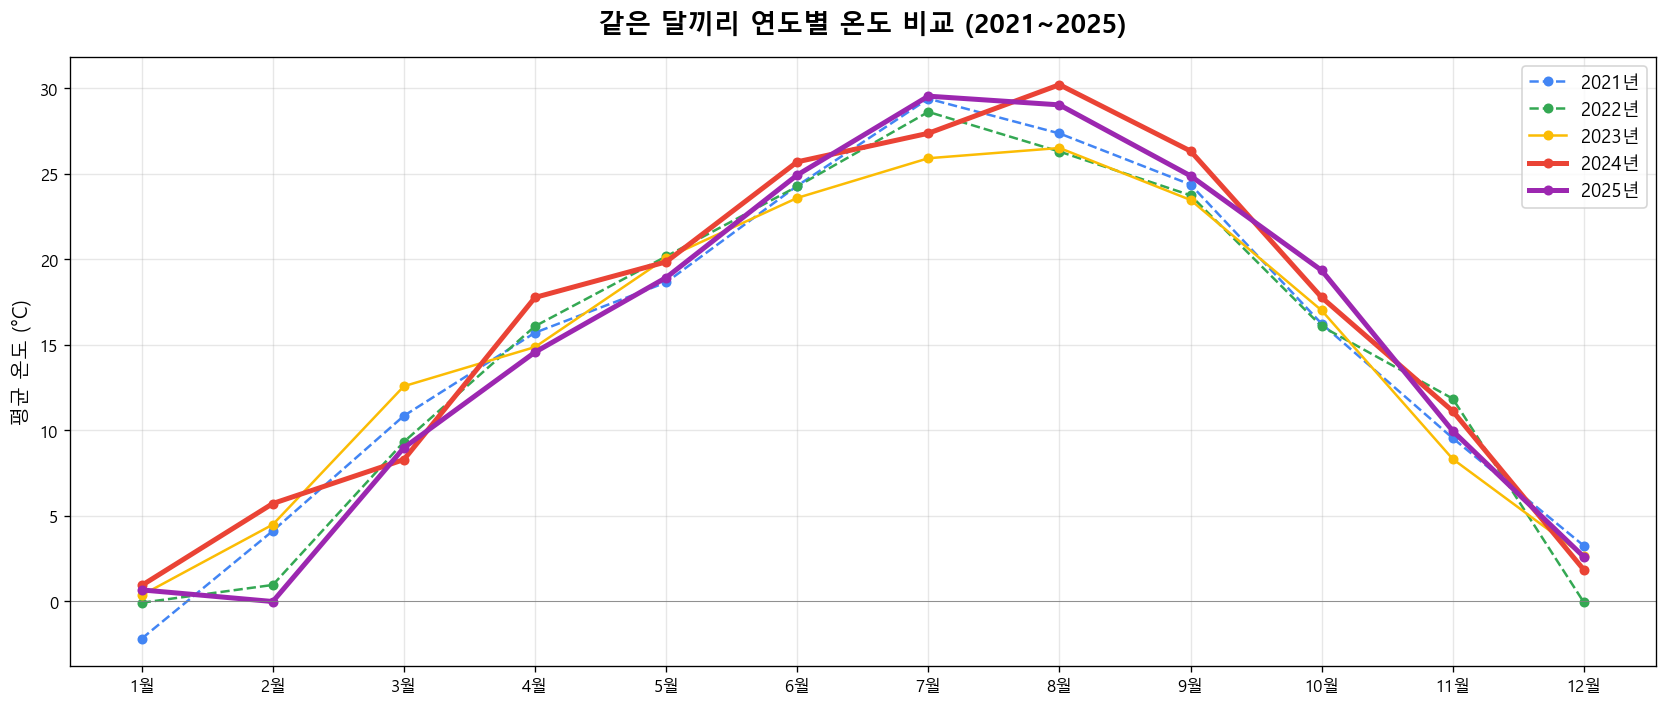

** 2024년 8월: 30.2°C (역대 최고)
** 2024~2025년 여름이 뚜렷하게 상승
** 2024년 4월: 17.8°C (과거 5월 수준 → 봄이 사라지는 중)


In [4]:
# ============================================================
# 같은 달끼리 연도별 비교 (월별 온도 트렌드)
# 목적: "특정 달이 예전보다 더워졌는가?" 확인
# 예: 2021년 8월 vs 2024년 8월 비교
# ============================================================

# [1] SQL로 연도-월별 평균 온도 조회
df_monthly = query("""
SELECT YEAR(등록일시) as year,           -- 연도 추출
       MONTH(등록일시) as month,         -- 월 추출 (1~12)
       ROUND(AVG(온도_평균), 2) as avg_temp  -- 해당 연도-월의 평균 온도
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
GROUP BY YEAR(등록일시), MONTH(등록일시)  -- 연도와 월 조합으로 그룹화
ORDER BY year, month                      -- 연도순, 월순 정렬
""")

# [2] X축에 표시할 한글 월 이름 리스트
months_kr = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

# [3] 연도별 색상 지정 (딕셔너리)
# 딕셔너리 = {키: 값} 형태로 데이터를 저장하는 자료구조
colors = {
    2021: '#4285F4',  # 파랑 (구글 블루)
    2022: '#34A853',  # 초록 (구글 그린)
    2023: '#FBBC04',  # 노랑 (구글 옐로)
    2024: '#EA4335',  # 빨강 (구글 레드) - 강조
    2025: '#9C27B0'   # 보라 - 최신 연도 강조
}

# [4] 그래프 캔버스 생성
fig, ax = plt.subplots(figsize=(14, 6))

# [5] 연도별로 반복하면서 꺾은선 그리기
for yr in [2021, 2022, 2023, 2024, 2025]:
    # 해당 연도 데이터만 필터링
    subset = df_monthly[df_monthly['year'] == yr]
    
    # 최근 연도(2024~)는 굵게, 과거 연도는 얇게
    lw = 3 if yr >= 2024 else 1.5  # lw = linewidth (선 두께)
    
    # 과거 연도(~2022)는 점선, 최근 연도는 실선
    ls = '--' if yr <= 2022 else '-'  # ls = linestyle (선 스타일)
    
    # 꺾은선 그래프 그리기
    # f'{ls}o' = 선스타일 + 동그라미 마커 (예: '--o' = 점선+동그라미)
    ax.plot(subset['month'], subset['avg_temp'], f'{ls}o',
            color=colors[yr],   # 연도별 색상
            linewidth=lw,       # 선 두께
            markersize=5,       # 마커 크기
            label=f'{yr}년')    # 범례 라벨

# [6] X축 설정
ax.set_xticks(range(1, 13))        # X축 눈금: 1~12
ax.set_xticklabels(months_kr)      # 눈금 라벨을 한글 월로

# [7] 기타 설정
ax.set_ylabel('평균 온도 (°C)', fontsize=12)
ax.set_title('같은 달끼리 연도별 온도 비교 (2021~2025)', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11)             # 범례 표시
ax.grid(alpha=0.3)                 # 격자선 (연하게)
ax.axhline(y=0, color='gray', linewidth=0.5)  # Y=0 기준선 (영하 구분용)

plt.tight_layout()
plt.show()

# ★ 발표 포인트
print('** 2024년 8월: 30.2°C (역대 최고)')
print('** 2024~2025년 여름이 뚜렷하게 상승')
print('** 2024년 4월: 17.8°C (과거 5월 수준 → 봄이 사라지는 중)')

---
## 4. 연도-월별 온도 히트맵

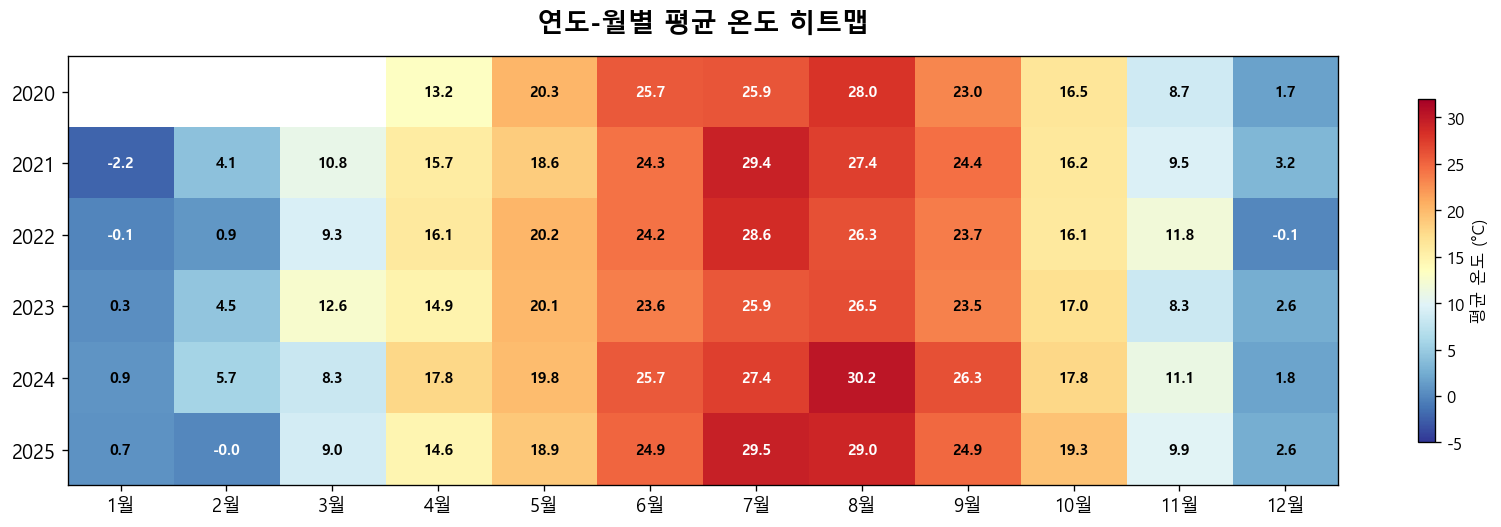

** 빨간색이 진할수록 고온, 파란색이 진할수록 저온
** 2024~2025년 여름 고온 영역이 5월~9월까지 확대되는 추세


In [5]:
# ============================================================
# 연도-월별 온도 히트맵 (Heatmap)
# 목적: 전체 데이터를 한눈에 조망 - 어느 연도, 어느 달이 더웠는지 색으로 표현
# 히트맵 = 숫자 데이터를 색상 농도로 시각화한 표
# ============================================================

import numpy as np  # numpy: 수치 계산용 라이브러리 (배열 연산에 특화)

# [1] 피벗 테이블 생성
# pivot() = 행과 열을 재배치해서 2차원 표 만들기
# 원본: year | month | avg_temp (세로로 긴 형태)
# 피벗 후: 행=year, 열=month, 값=avg_temp (매트릭스 형태)
pivot = df_monthly[
    (df_monthly['year'] >= 2020) & (df_monthly['year'] <= 2025)
].pivot(
    index='year',        # 행(세로축)에 연도
    columns='month',     # 열(가로축)에 월
    values='avg_temp'    # 셀 값에 평균 온도
)
pivot.columns = months_kr  # 열 이름을 한글 월로 변경

# [2] 히트맵 그리기
fig, ax = plt.subplots(figsize=(14, 4.5))

# imshow() = 2D 배열을 이미지(색상 맵)로 표시
# cmap = 'RdYlBu_r' : Red-Yellow-Blue 색상맵의 역순 (_r = reverse)
#        빨강(고온) → 노랑(중간) → 파랑(저온)
# vmin, vmax = 색상 범위의 최소/최대값
im = ax.imshow(pivot.values, cmap='RdYlBu_r', aspect='auto', vmin=-5, vmax=32)

# [3] 축 눈금 설정
ax.set_xticks(range(12))                    # X축: 0~11 (12개월)
ax.set_xticklabels(months_kr, fontsize=11)  # 라벨을 한글 월로
ax.set_yticks(range(len(pivot)))            # Y축: 0~5 (6개년)
ax.set_yticklabels(pivot.index, fontsize=12)  # 라벨을 연도로

# [4] 각 셀에 온도값 텍스트 표시
# 이중 for문으로 모든 셀(i행 j열)을 순회
for i in range(len(pivot)):          # i = 행 인덱스 (연도)
    for j in range(12):              # j = 열 인덱스 (월)
        val = pivot.values[i, j]     # 해당 셀의 온도값
        if not np.isnan(val):        # NaN(결측치)이 아닐 때만 표시
            # 고온(>25) 또는 저온(<0)일 때는 흰색 글씨, 그 외는 검정 글씨
            # (배경색이 진하면 흰색이 잘 보임)
            color = 'white' if val > 25 or val < 0 else 'black'
            ax.text(j, i, f'{val:.1f}',  # :.1f = 소수점 1자리
                    ha='center', va='center',  # 가로/세로 가운데 정렬
                    fontsize=9, fontweight='bold', color=color)

# [5] 컬러바 추가 (색상이 무슨 온도인지 설명하는 막대)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)  # shrink = 컬러바 크기 비율
cbar.set_label('평균 온도 (°C)', fontsize=10)

# [6] 제목 및 레이아웃
ax.set_title('연도-월별 평균 온도 히트맵', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ★ 발표 포인트
print('** 빨간색이 진할수록 고온, 파란색이 진할수록 저온')
print('** 2024~2025년 여름 고온 영역이 5월~9월까지 확대되는 추세')

---
## 5. 계절별 온도 추이

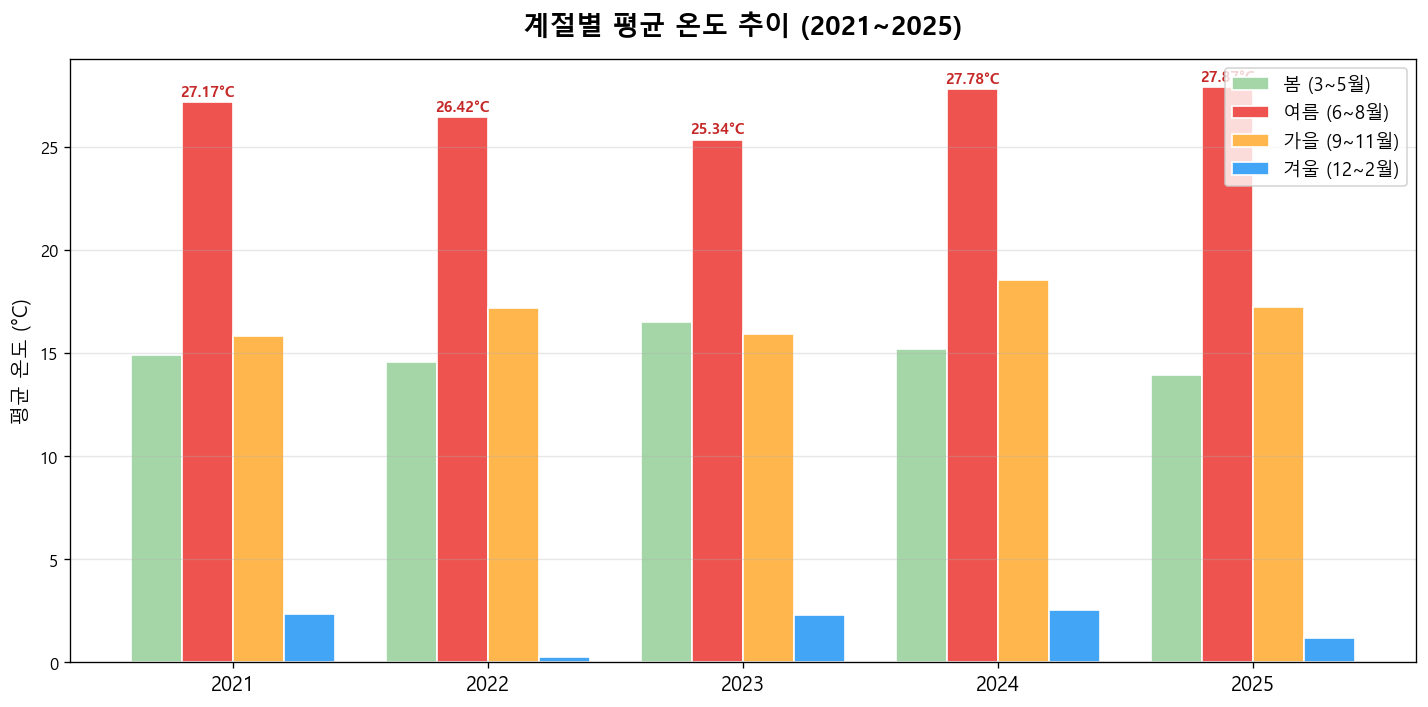

** 여름: 25.3°C(2023) → 27.8°C(2024) → 27.9°C(2025) 연속 상승
** 가을: 15.8°C(2021) → 18.5°C(2024) +2.7°C 상승 (가을이 따뜻해지고 있다)


In [6]:
# ============================================================
# 계절별 온도 추이 분석
# 목적: 봄/여름/가을/겨울 각각 어떻게 변화하고 있는지 확인
# ============================================================

# [1] SQL로 계절별 평균 온도 계산
# CASE WHEN = 조건에 따라 다른 값을 반환 (if-else와 유사)
# CASE WHEN 조건 THEN 값 END = "조건이 참이면 값 사용, 아니면 NULL"
df_season = query("""
SELECT YEAR(등록일시) as year,
  -- 봄: 3,4,5월 데이터만 평균
  ROUND(AVG(CASE WHEN MONTH(등록일시) IN (3,4,5) THEN 온도_평균 END),2) as spring,
  -- 여름: 6,7,8월 데이터만 평균
  ROUND(AVG(CASE WHEN MONTH(등록일시) IN (6,7,8) THEN 온도_평균 END),2) as summer,
  -- 가을: 9,10,11월 데이터만 평균
  ROUND(AVG(CASE WHEN MONTH(등록일시) IN (9,10,11) THEN 온도_평균 END),2) as autumn,
  -- 겨울: 12,1,2월 데이터만 평균
  ROUND(AVG(CASE WHEN MONTH(등록일시) IN (12,1,2) THEN 온도_평균 END),2) as winter
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50    -- 이상치(비정상 값) 제외
AND YEAR(등록일시) BETWEEN 2021 AND 2025  -- 완전 연도만
GROUP BY YEAR(등록일시)
ORDER BY year
""")

# [2] 그룹화된 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(12, 6))

# X축 위치 설정
# np.arange(n) = [0, 1, 2, ..., n-1] 배열 생성
x = np.arange(len(df_season))  # [0, 1, 2, 3, 4] (5개년)
w = 0.2  # 막대 너비 (4개 계절이 나란히 들어가야 하므로 좁게)

# [3] 계절별 막대 그래프
# x - 1.5*w = 막대 위치를 왼쪽으로 이동 (4개 막대가 겹치지 않게)
bars1 = ax.bar(x - 1.5*w, df_season['spring'], w, 
               label='봄 (3~5월)', color='#A5D6A7', edgecolor='white')
bars2 = ax.bar(x - 0.5*w, df_season['summer'], w, 
               label='여름 (6~8월)', color='#EF5350', edgecolor='white')
bars3 = ax.bar(x + 0.5*w, df_season['autumn'], w, 
               label='가을 (9~11월)', color='#FFB74D', edgecolor='white')
bars4 = ax.bar(x + 1.5*w, df_season['winter'], w, 
               label='겨울 (12~2월)', color='#42A5F5', edgecolor='white')

# [4] 여름 막대 위에 온도값 표시 (핵심 데이터 강조)
# zip() = 두 리스트를 짝지어서 순회
for bar, val in zip(bars2, df_season['summer']):
    ax.text(
        bar.get_x() + bar.get_width()/2,  # 막대 중앙 X좌표
        bar.get_height() + 0.3,            # 막대 높이 + 여백
        f'{val}°C',                        # 표시할 텍스트
        ha='center', fontsize=9, fontweight='bold', color='#c62828'
    )

# [5] X축 설정
ax.set_xticks(x)                              # X축 눈금 위치
ax.set_xticklabels(df_season['year'], fontsize=12)  # 연도 라벨

# [6] 기타 설정
ax.set_ylabel('평균 온도 (°C)', fontsize=12)
ax.set_title('계절별 평균 온도 추이 (2021~2025)', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11)  # 범례 표시
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ★ 발표 포인트
print('** 여름: 25.3°C(2023) → 27.8°C(2024) → 27.9°C(2025) 연속 상승')
print('** 가을: 15.8°C(2021) → 18.5°C(2024) +2.7°C 상승 (가을이 따뜻해지고 있다)')

---
## 6. 구별 평균 온도 랭킹

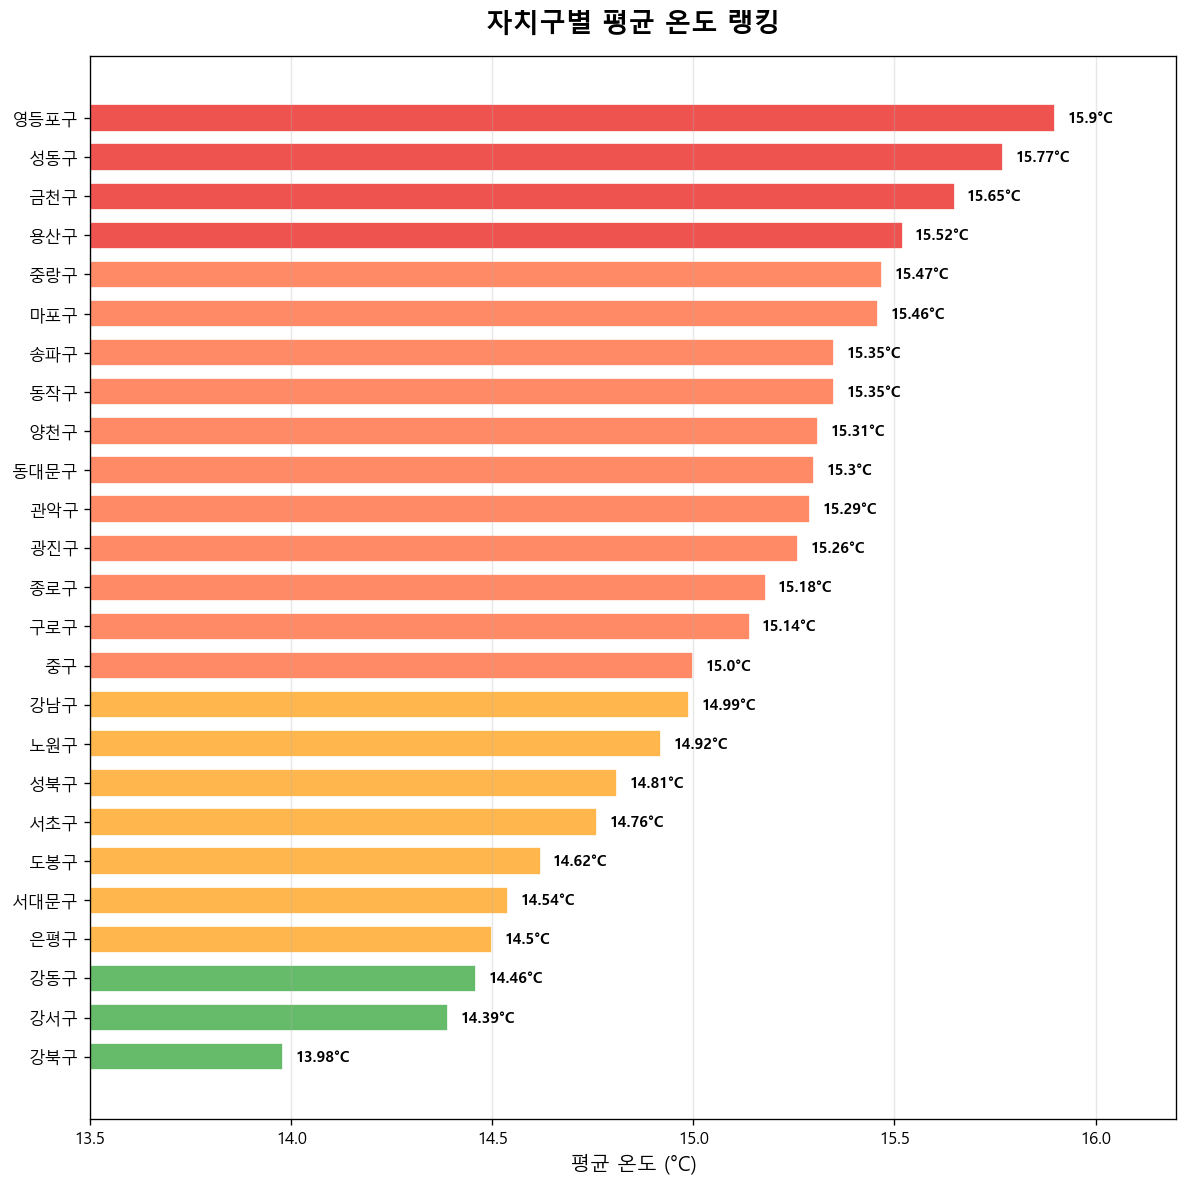


가장 뜨거운 구: 영등포구 (15.9°C)
가장 시원한 구: 강북구 (13.98°C)
최대 온도 격차: 1.92°C


In [7]:
# ============================================================
# 자치구별 평균 온도 랭킹
# 목적: 서울에서 가장 더운 구 vs 가장 시원한 구 비교
# ============================================================

# [1] SQL로 자치구별 평균 온도/습도 조회
df_dist = query("""
SELECT 자치구, 
       ROUND(AVG(온도_평균),2) as avg_temp,   -- 구별 평균 온도
       ROUND(AVG(습도_평균),2) as avg_humid   -- 구별 평균 습도
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
GROUP BY 자치구                               -- 자치구별로 그룹화
ORDER BY avg_temp DESC                        -- 온도 높은 순 정렬
""")

# [2] 영문 자치구명 → 한글 변환 딕셔너리
# DB에 영문으로 저장되어 있어서 한글로 변환 필요
gu_map = {
    'Gangnam-gu':'강남구','Gangdong-gu':'강동구','Gangbuk-gu':'강북구',
    'Gangseo-gu':'강서구','Gwanak-gu':'관악구','Gwangjin-gu':'광진구',
    'Guro-gu':'구로구','Geumcheon-gu':'금천구','Nowon-gu':'노원구',
    'Dobong-gu':'도봉구','Dongdaemun-gu':'동대문구','Dongjak-gu':'동작구',
    'Mapo-gu':'마포구','Seodaemun-gu':'서대문구','Seocho-gu':'서초구',
    'Seongdong-gu':'성동구','Seongbuk-gu':'성북구','Songpa-gu':'송파구',
    'Yangcheon-gu':'양천구','Yeongdeungpo-gu':'영등포구','Yongsan-gu':'용산구',
    'Eunpyeong-gu':'은평구','Jongno-gu':'종로구','Jung-gu':'중구',
    'Jungnang-gu':'중랑구'
}
# .map() = 값을 딕셔너리에 따라 변환
df_dist['구이름'] = df_dist['자치구'].map(gu_map)

# [3] 수평 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 10))

# [4] 온도에 따라 색상 다르게 (조건부 색상)
# 리스트 컴프리헨션 = 반복문을 한 줄로 작성하는 파이썬 문법
# [결과값 for 변수 in 리스트 if 조건]
colors_bar = [
    '#EF5350' if t >= 15.5 else      # 15.5°C 이상 = 빨강 (가장 뜨거움)
    '#FF8A65' if t >= 15.0 else      # 15.0°C 이상 = 주황
    '#FFB74D' if t >= 14.5 else      # 14.5°C 이상 = 노랑
    '#66BB6A'                         # 나머지 = 초록 (시원함)
    for t in df_dist['avg_temp']      # 각 구의 온도에 대해 반복
]

# [5] 수평 막대 그래프 (barh = bar horizontal)
bars = ax.barh(df_dist['구이름'], df_dist['avg_temp'], 
               color=colors_bar, edgecolor='white', height=0.7)

# [6] X축 범위 설정 (온도 차이를 잘 보이게 좁은 범위로)
ax.set_xlim(13.5, 16.2)
ax.set_xlabel('평균 온도 (°C)', fontsize=12)
ax.set_title('자치구별 평균 온도 랭킹', fontsize=16, fontweight='bold', pad=15)

# [7] Y축 순서 뒤집기 (1위가 맨 위로)
ax.invert_yaxis()

# [8] 막대 끝에 온도값 표시
for bar, val in zip(bars, df_dist['avg_temp']):
    ax.text(
        bar.get_width() + 0.03,           # 막대 끝에서 약간 오른쪽
        bar.get_y() + bar.get_height()/2, # 막대 세로 중앙
        f'{val}°C',
        va='center', fontsize=9, fontweight='bold'
    )

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ★ 발표 포인트: 결과 출력
# .iloc[0] = 첫 번째 행 (가장 뜨거운 구)
# .iloc[-1] = 마지막 행 (가장 시원한 구)
print(f'\n가장 뜨거운 구: {df_dist.iloc[0]["구이름"]} ({df_dist.iloc[0]["avg_temp"]}°C)')
print(f'가장 시원한 구: {df_dist.iloc[-1]["구이름"]} ({df_dist.iloc[-1]["avg_temp"]}°C)')
print(f'최대 온도 격차: {df_dist["avg_temp"].max() - df_dist["avg_temp"].min():.2f}°C')

---
## 7. 여름 폭염 심화 추이

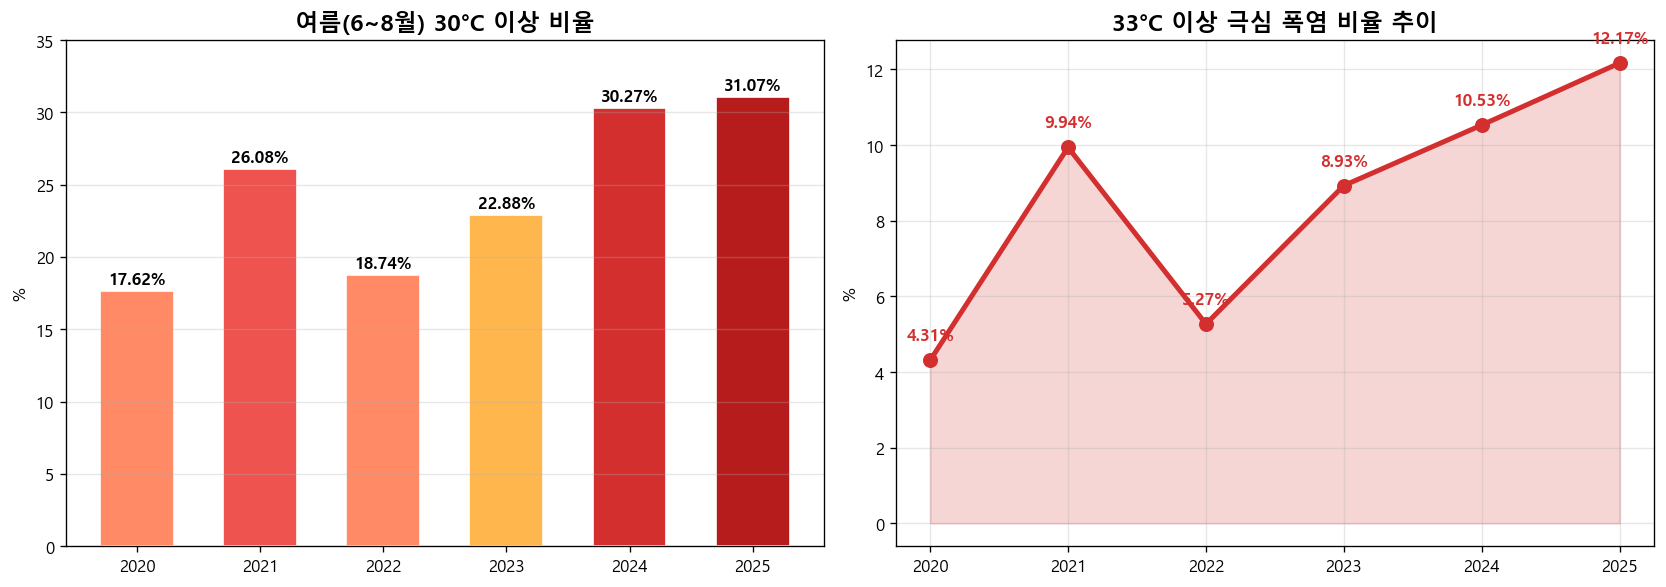

** 30°C 이상: 17.6%(2020) → 31.1%(2025) 약 2배 증가
** 33°C 이상: 4.3%(2020) → 12.2%(2025) 약 3배 증가


In [8]:
# ============================================================
# 여름 폭염 심화 추이 분석
# 목적: "폭염이 정말 심해지고 있는가?"를 수치로 증명
# ============================================================

# [1] SQL로 연도별 폭염 비율 계산
# 폭염 기준: 30°C 이상 / 극심 폭염: 33°C 이상
df_heat = query("""
SELECT YEAR(등록일시) as year,
  -- 30°C 이상 비율 계산 공식:
  -- COUNT(CASE WHEN 조건 THEN 1 END) = 조건을 만족하는 행 개수
  -- * 100.0 = 정수 나눗셈 방지 (퍼센트로 환산)
  -- / COUNT(*) = 전체 행 개수로 나눔
  ROUND(COUNT(CASE WHEN 온도_평균 >= 30 THEN 1 END) * 100.0 / COUNT(*), 2) as hot_pct,
  -- 33°C 이상 극심 폭염 비율
  ROUND(COUNT(CASE WHEN 온도_평균 >= 33 THEN 1 END) * 100.0 / COUNT(*), 2) as extreme_pct
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50          -- 이상치 제외
AND MONTH(등록일시) IN (6,7,8)                   -- 여름(6~8월)만
AND YEAR(등록일시) BETWEEN 2020 AND 2025
GROUP BY YEAR(등록일시)
ORDER BY year
""")

# [2] 2개의 서브플롯 (1행 2열)
# subplots(행, 열) = 여러 그래프를 한 화면에 배치
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# [3] 왼쪽 그래프: 30°C 이상 비율 막대 그래프
# 연도별로 다른 색상 (2024~2025가 가장 진한 빨강)
c1 = ['#FF8A65','#EF5350','#FF8A65','#FFB74D','#D32F2F','#B71C1C']
bars1 = ax1.bar(df_heat['year'], df_heat['hot_pct'], 
                color=c1, edgecolor='white', width=0.6)
ax1.set_title('여름(6~8월) 30°C 이상 비율', fontsize=14, fontweight='bold')
ax1.set_ylabel('%')
ax1.set_ylim(0, 35)  # Y축 범위 고정

# 막대 위에 값 표시
for bar, val in zip(bars1, df_heat['hot_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# [4] 오른쪽 그래프: 33°C 이상 극심 폭염 추이
# fill_between() = 선 아래 영역을 색으로 채움 (영역 차트)
ax2.fill_between(df_heat['year'], df_heat['extreme_pct'], 
                 alpha=0.2, color='#D32F2F')  # alpha=0.2 : 연한 빨강 배경
# 그 위에 꺾은선 그래프
ax2.plot(df_heat['year'], df_heat['extreme_pct'], 'o-', 
         color='#D32F2F', linewidth=3, markersize=8)
ax2.set_title('33°C 이상 극심 폭염 비율 추이', fontsize=14, fontweight='bold')
ax2.set_ylabel('%')

# 각 점 위에 값 표시
for x, y in zip(df_heat['year'], df_heat['extreme_pct']):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=10, fontweight='bold', color='#D32F2F')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ★ 발표 포인트
print('** 30°C 이상: 17.6%(2020) → 31.1%(2025) 약 2배 증가')
print('** 33°C 이상: 4.3%(2020) → 12.2%(2025) 약 3배 증가')

---
## 8. 열대야: 밤에도 잠 못 드는 서울

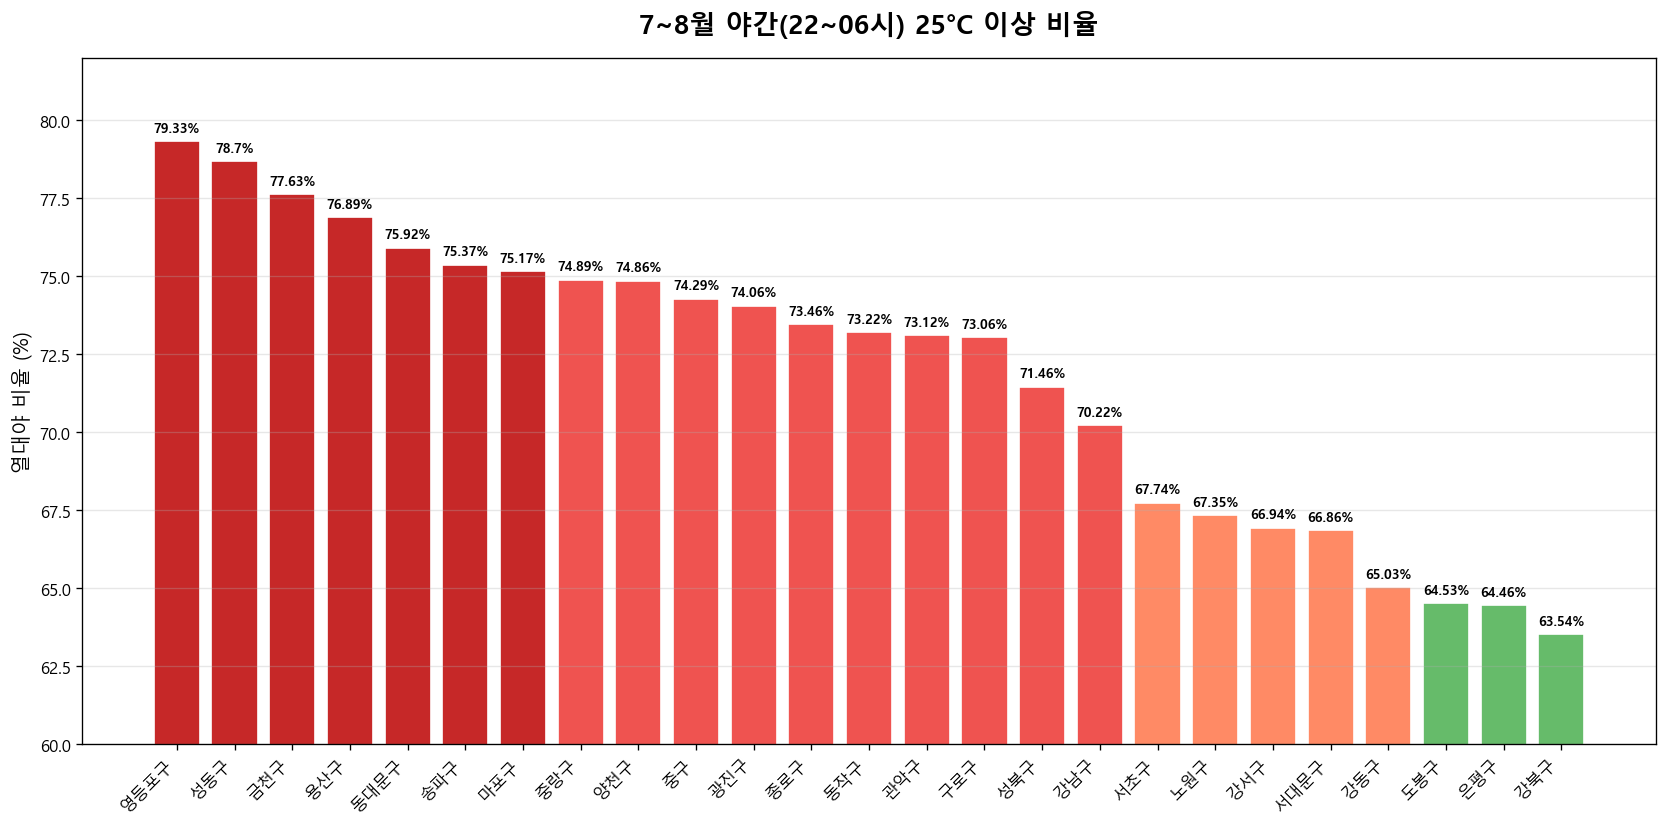

열대야 최다: 영등포구 (79.33%)
열대야 최소: 강북구 (63.54%)


In [9]:
# ============================================================
# 열대야 분석: 밤에도 잠 못 드는 서울
# 열대야 = 밤(18시~익일 9시)에 최저기온이 25°C 이상인 현상
# 여기서는 야간(22시~06시) 평균 25°C 이상 비율로 측정
# ============================================================

# [1] SQL로 자치구별 열대야 비율 계산
df_trop = query("""
SELECT 자치구,
  -- 야간 25°C 이상 비율 = (조건 만족 건수 / 전체 건수) * 100
  ROUND(COUNT(CASE WHEN 온도_평균 >= 25 THEN 1 END) * 100.0 / COUNT(*), 2) as tropical_pct
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50
AND MONTH(등록일시) IN (7,8)                          -- 7~8월 (열대야 집중 시기)
AND (HOUR(등록일시) >= 22 OR HOUR(등록일시) <= 6)     -- 야간 시간대 (22시~6시)
                                                       -- OR 사용: 22,23,0,1,2,3,4,5,6시
GROUP BY 자치구
ORDER BY tropical_pct DESC                             -- 열대야 많은 순 정렬
""")

# [2] 영문 → 한글 변환 (위에서 정의한 gu_map 재사용)
df_trop['구이름'] = df_trop['자치구'].map(gu_map)

# [3] 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 7))

# [4] 열대야 비율에 따른 색상 (높을수록 진한 빨강)
colors_trop = [
    '#C62828' if p >= 75 else   # 75% 이상 = 가장 진한 빨강 (심각)
    '#EF5350' if p >= 70 else   # 70% 이상 = 빨강
    '#FF8A65' if p >= 65 else   # 65% 이상 = 주황
    '#66BB6A'                    # 나머지 = 초록 (양호)
    for p in df_trop['tropical_pct']
]

# [5] 수직 막대 그래프
bars = ax.bar(df_trop['구이름'], df_trop['tropical_pct'], 
              color=colors_trop, edgecolor='white')

# [6] Y축 범위 (차이를 잘 보이게 60~82%로 설정)
ax.set_ylim(60, 82)
ax.set_ylabel('열대야 비율 (%)', fontsize=12)
ax.set_title('7~8월 야간(22~06시) 25°C 이상 비율', fontsize=16, fontweight='bold', pad=15)

# [7] X축 라벨 회전 (구 이름이 겹치지 않게)
plt.xticks(rotation=45, ha='right')  # 45도 회전, 오른쪽 정렬

# [8] 막대 위에 값 표시
for bar, val in zip(bars, df_trop['tropical_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=8, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ★ 발표 포인트
print(f'열대야 최다: {df_trop.iloc[0]["구이름"]} ({df_trop.iloc[0]["tropical_pct"]}%)')
print(f'열대야 최소: {df_trop.iloc[-1]["구이름"]} ({df_trop.iloc[-1]["tropical_pct"]}%)')

---
## 9. 하루 24시간 온도-습도 리듬

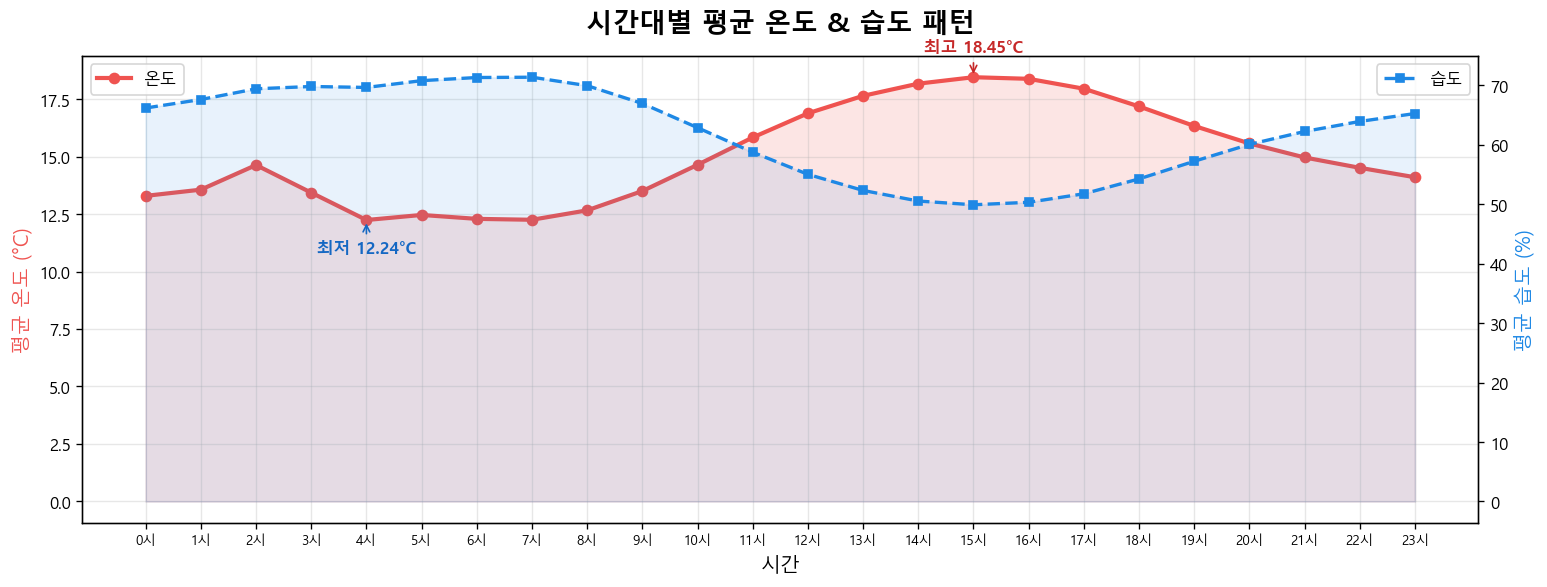

** 온도와 습도는 완벽한 역상관 관계
** 가장 더운 시간: 오후 3시(18.5°C), 가장 추운 시간: 오전 7시(12.3°C)


In [10]:
# ============================================================
# 하루 24시간 온도-습도 리듬 분석
# 목적: 하루 중 언제가 가장 덥고, 언제가 가장 시원한지 파악
# ============================================================

# [1] SQL로 시간대별 평균 온도/습도 조회
# HOUR() = 시간 추출 (2024-08-15 14:30:00 → 14)
df_hour = query("""
SELECT HOUR(등록일시) as hour,              -- 0~23시
       ROUND(AVG(온도_평균), 2) as avg_temp,
       ROUND(AVG(습도_평균), 2) as avg_humid
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50
GROUP BY HOUR(등록일시)
ORDER BY hour
""")

# [2] 이중 축 그래프 (온도 + 습도)
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()  # 오른쪽 Y축 추가

# [3] 온도 그래프 (왼쪽 Y축) - 영역 차트 + 꺾은선
# fill_between() = 선 아래 영역을 색으로 채움
ax1.fill_between(df_hour['hour'], df_hour['avg_temp'], alpha=0.15, color='#EF5350')
ax1.plot(df_hour['hour'], df_hour['avg_temp'], 'o-', 
         color='#EF5350', linewidth=2.5, markersize=6, label='온도')

# [4] 습도 그래프 (오른쪽 Y축) - 영역 차트 + 꺾은선
ax2.fill_between(df_hour['hour'], df_hour['avg_humid'], alpha=0.1, color='#1E88E5')
# 's--' = 사각형(s) 마커 + 점선(--)
ax2.plot(df_hour['hour'], df_hour['avg_humid'], 's--', 
         color='#1E88E5', linewidth=2, markersize=5, label='습도')

# [5] 축 라벨 설정
ax1.set_xlabel('시간', fontsize=12)
ax1.set_ylabel('평균 온도 (°C)', color='#EF5350', fontsize=12)
ax2.set_ylabel('평균 습도 (%)', color='#1E88E5', fontsize=12)

# [6] X축 눈금 설정 (0~23시를 한글로)
ax1.set_xticks(range(24))
ax1.set_xticklabels([f'{h}시' for h in range(24)], fontsize=8)

# [7] 최고/최저 온도 지점에 화살표 주석 추가
# idxmax() = 최댓값의 인덱스 반환
# idxmin() = 최솟값의 인덱스 반환
max_idx = df_hour['avg_temp'].idxmax()  # 가장 더운 시간
min_idx = df_hour['avg_temp'].idxmin()  # 가장 추운 시간

# 최고 온도 주석 (화살표 포함)
ax1.annotate(
    f"최고 {df_hour.loc[max_idx,'avg_temp']}°C",  # 표시 텍스트
    (df_hour.loc[max_idx,'hour'], df_hour.loc[max_idx,'avg_temp']),  # 화살표 끝점
    textcoords='offset points', xytext=(0, 15),   # 텍스트 위치 (위로 15pt)
    ha='center', fontsize=10, fontweight='bold', color='#c62828',
    arrowprops=dict(arrowstyle='->', color='#c62828')  # 화살표 스타일
)

# 최저 온도 주석
ax1.annotate(
    f"최저 {df_hour.loc[min_idx,'avg_temp']}°C",
    (df_hour.loc[min_idx,'hour'], df_hour.loc[min_idx,'avg_temp']),
    textcoords='offset points', xytext=(0, -20),  # 아래로 20pt
    ha='center', fontsize=10, fontweight='bold', color='#1565C0',
    arrowprops=dict(arrowstyle='->', color='#1565C0')
)

# [8] 제목, 범례, 격자
ax1.set_title('시간대별 평균 온도 & 습도 패턴', fontsize=16, fontweight='bold', pad=15)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ★ 발표 포인트
print('** 온도와 습도는 완벽한 역상관 관계')
print('** 가장 더운 시간: 오후 3시(18.5°C), 가장 추운 시간: 오전 7시(12.3°C)')

---
## 10. 도시 열섬효과: 여름 낮 vs 밤 온도차

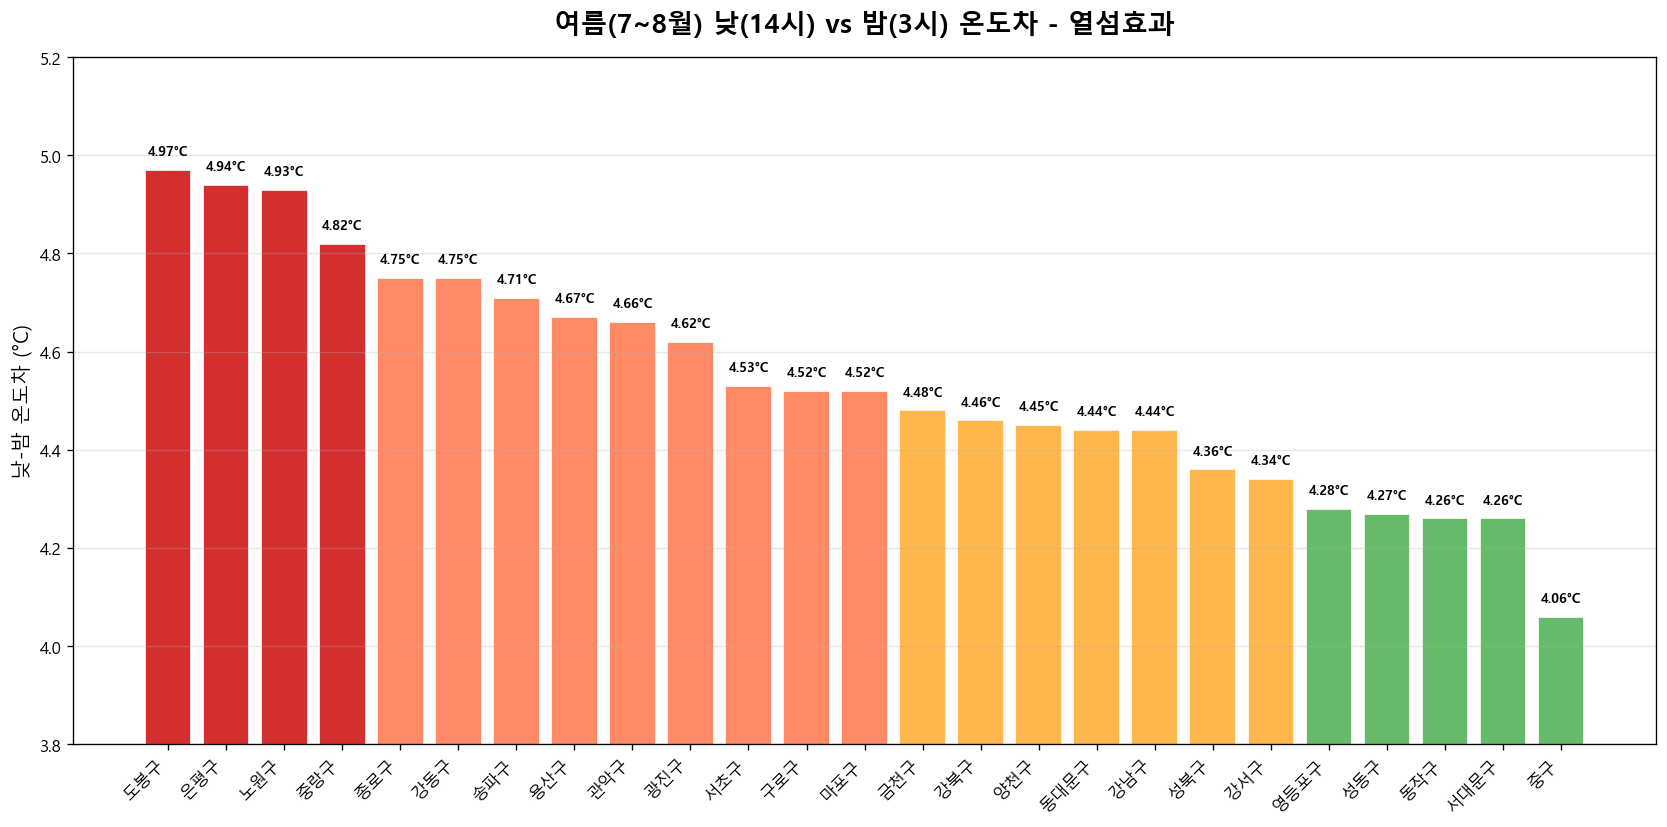

열섬효과 최대: 도봉구 (4.97°C)
열섬효과 최소: 중구 (4.06°C)


In [11]:
# ============================================================
# 도시 열섬효과(Urban Heat Island) 분석
# 열섬효과 = 도심이 주변보다 더 뜨거운 현상
#           콘크리트/아스팔트가 열을 흡수했다가 밤에 방출
# 낮-밤 온도차가 작을수록 열섬효과가 심함 (밤에도 안 식음)
# ============================================================

# [1] SQL로 자치구별 낮(14시) vs 밤(3시) 온도 비교
# 서브쿼리 2개를 JOIN으로 합침
df_island = query("""
SELECT a.자치구,
  ROUND(a.day_temp,2) as day_temp,       -- 낮(14시) 평균 온도
  ROUND(b.night_temp,2) as night_temp,   -- 밤(3시) 평균 온도
  ROUND(a.day_temp - b.night_temp,2) as temp_diff  -- 낮-밤 온도차
FROM (
  -- 서브쿼리 a: 낮(14시) 온도
  SELECT 자치구, AVG(온도_평균) as day_temp
  FROM sdot_nature_all
  WHERE MONTH(등록일시) IN (7,8)          -- 여름(7~8월)
    AND HOUR(등록일시) = 14               -- 오후 2시 (하루 중 가장 더운 시간대)
    AND 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
    AND 온도_평균 > -30 AND 온도_평균 < 50
  GROUP BY 자치구
) a
JOIN (
  -- 서브쿼리 b: 밤(3시) 온도
  SELECT 자치구, AVG(온도_평균) as night_temp
  FROM sdot_nature_all
  WHERE MONTH(등록일시) IN (7,8)          -- 여름(7~8월)
    AND HOUR(등록일시) = 3                -- 새벽 3시 (하루 중 가장 서늘한 시간대)
    AND 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
    AND 온도_평균 > -30 AND 온도_평균 < 50
  GROUP BY 자치구
) b ON a.자치구 = b.자치구                -- 같은 자치구끼리 연결
ORDER BY temp_diff DESC                   -- 온도차 큰 순 정렬
""")

# [2] 영문 → 한글 변환
df_island['구이름'] = df_island['자치구'].map(gu_map)

# [3] 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 7))

# [4] 온도차에 따른 색상
# 온도차가 클수록 초록 (밤에 잘 식음 = 양호)
# 온도차가 작을수록 빨강 (밤에 안 식음 = 열섬효과 심함)
colors_isl = [
    '#D32F2F' if d >= 4.8 else   # 4.8°C 이상 차이 = 빨강? (사실 차이가 클수록 좋음)
    '#FF8A65' if d >= 4.5 else   # 여기서는 단순 시각화를 위한 색상 구분
    '#FFB74D' if d >= 4.3 else
    '#66BB6A'
    for d in df_island['temp_diff']
]

# [5] 수직 막대 그래프
bars = ax.bar(df_island['구이름'], df_island['temp_diff'], 
              color=colors_isl, edgecolor='white')

# [6] Y축 범위 및 라벨
ax.set_ylim(3.8, 5.2)  # 차이를 잘 보이게 좁은 범위
ax.set_ylabel('낮-밤 온도차 (°C)', fontsize=12)
ax.set_title('여름(7~8월) 낮(14시) vs 밤(3시) 온도차 - 열섬효과', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')

# [7] 막대 위에 값 표시
for bar, val in zip(bars, df_island['temp_diff']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val}°C', ha='center', fontsize=8, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ★ 발표 포인트
# 주의: 이 차트에서는 온도차가 "작을수록" 열섬효과가 심함
print(f'열섬효과 최대: {df_island.iloc[0]["구이름"]} ({df_island.iloc[0]["temp_diff"]}°C)')
print(f'열섬효과 최소: {df_island.iloc[-1]["구이름"]} ({df_island.iloc[-1]["temp_diff"]}°C)')

---
## 11. 구별 여름 폭염 비율 (30°C 이상)

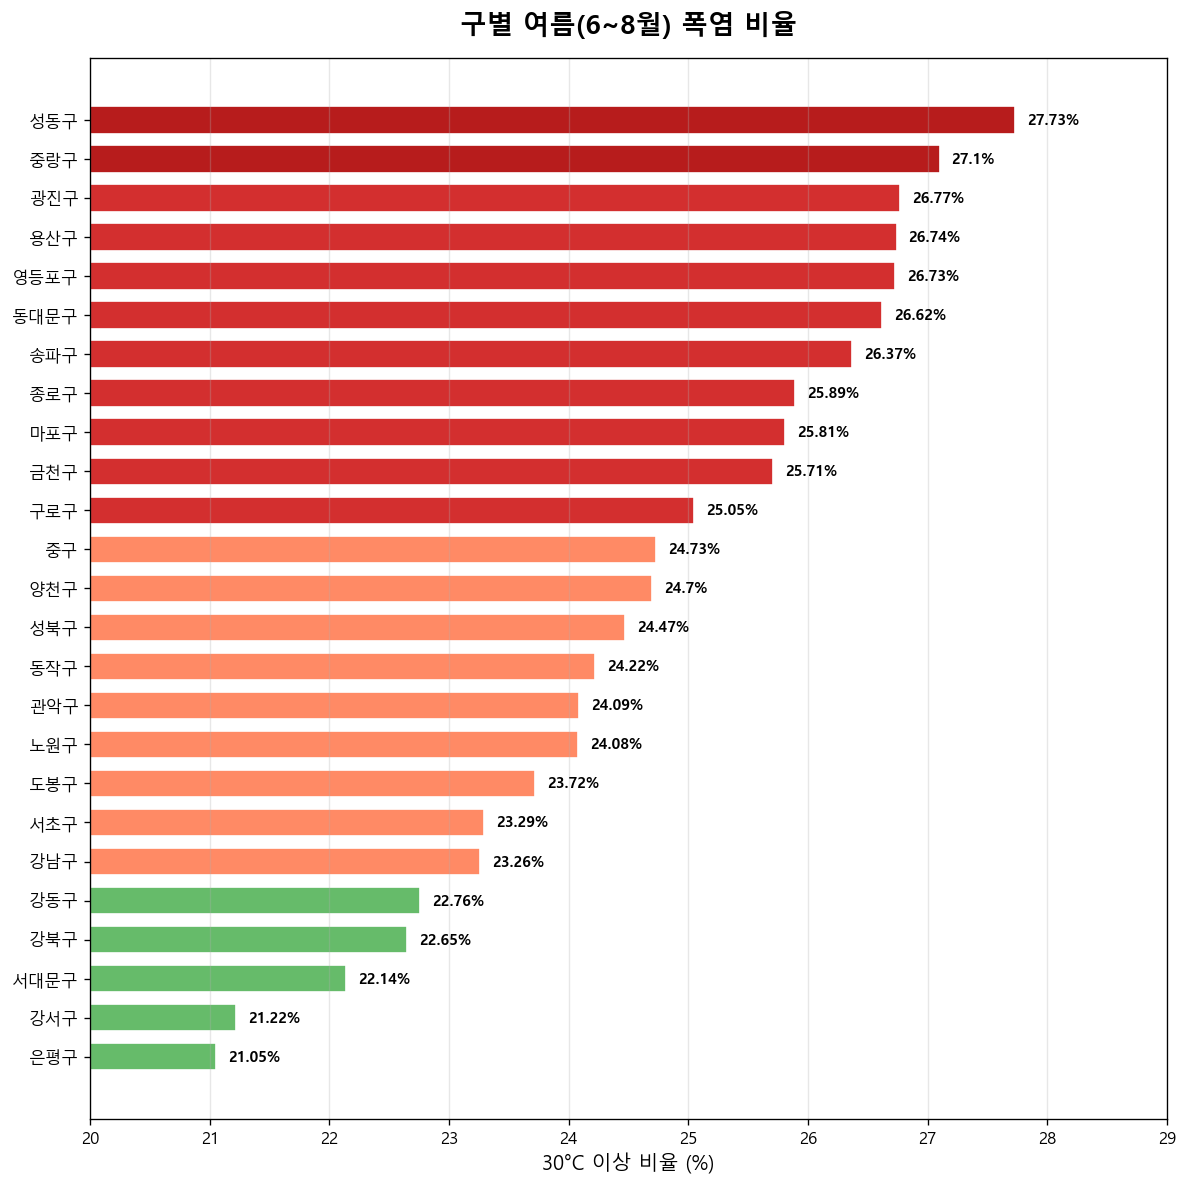

여름 폭염 최다: 성동구 (27.73%)
여름 폭염 최소: 은평구 (21.05%)


In [12]:
# ============================================================
# 구별 여름 폭염 비율 분석 (30°C 이상)
# 목적: 어느 구가 폭염에 가장 취약한지 파악
# ============================================================

# [1] SQL로 자치구별 폭염 비율 계산
df_dh = query("""
SELECT 자치구,
  -- 30°C 이상 비율 = (30도 이상 건수 / 전체 건수) * 100
  ROUND(COUNT(CASE WHEN 온도_평균 >= 30 THEN 1 END) * 100.0 / COUNT(*), 2) as heatwave_pct
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50
AND MONTH(등록일시) IN (6,7,8)            -- 여름(6~8월)만
GROUP BY 자치구
ORDER BY heatwave_pct DESC                -- 폭염 비율 높은 순
""")

# [2] 영문 → 한글 변환
df_dh['구이름'] = df_dh['자치구'].map(gu_map)

# [3] 수평 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 10))

# [4] 폭염 비율에 따른 색상 (높을수록 진한 빨강)
colors_dh = [
    '#B71C1C' if p >= 27 else   # 27% 이상 = 가장 진한 빨강
    '#D32F2F' if p >= 25 else   # 25% 이상 = 빨강
    '#FF8A65' if p >= 23 else   # 23% 이상 = 주황
    '#66BB6A'                    # 나머지 = 초록
    for p in df_dh['heatwave_pct']
]

# [5] 수평 막대 그래프
bars = ax.barh(df_dh['구이름'], df_dh['heatwave_pct'], 
               color=colors_dh, edgecolor='white', height=0.7)

# [6] X축 범위 및 라벨
ax.set_xlim(20, 29)  # 차이를 잘 보이게 좁은 범위
ax.set_xlabel('30°C 이상 비율 (%)', fontsize=12)
ax.set_title('구별 여름(6~8월) 폭염 비율', fontsize=16, fontweight='bold', pad=15)

# [7] Y축 순서 뒤집기 (1위가 맨 위로)
ax.invert_yaxis()

# [8] 막대 끝에 값 표시
for bar, val in zip(bars, df_dh['heatwave_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ★ 발표 포인트
print(f'여름 폭염 최다: {df_dh.iloc[0]["구이름"]} ({df_dh.iloc[0]["heatwave_pct"]}%)')
print(f'여름 폭염 최소: {df_dh.iloc[-1]["구이름"]} ({df_dh.iloc[-1]["heatwave_pct"]}%)')

---
## 12. 쾌적 지수: 가장 살기 좋은 구는?

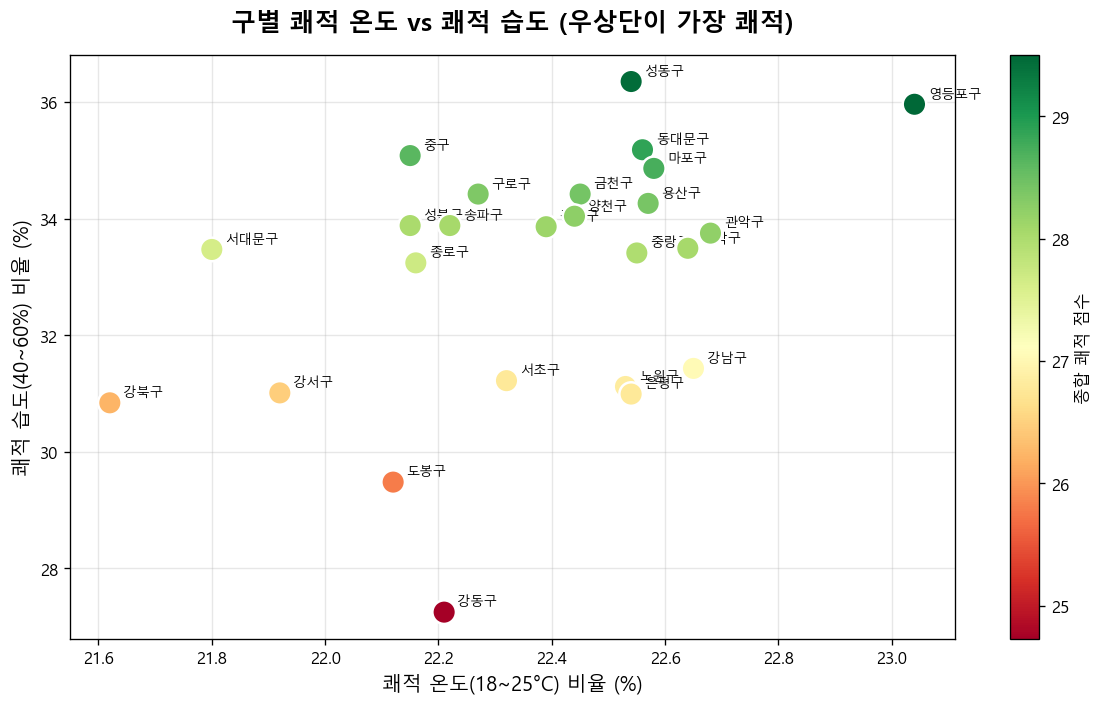


=== 쾌적 지수 TOP 5 ===
1위: 영등포구 (온도 23.04% + 습도 35.96% = 종합 29.5점)
2위: 성동구 (온도 22.54% + 습도 36.35% = 종합 29.4점)
3위: 동대문구 (온도 22.56% + 습도 35.18% = 종합 28.9점)
4위: 마포구 (온도 22.58% + 습도 34.86% = 종합 28.7점)
5위: 중구 (온도 22.15% + 습도 35.08% = 종합 28.6점)

=== 쾌적 지수 하위 5 ===
21위: 은평구 (온도 22.54% + 습도 30.99% = 종합 26.8점)
22위: 강서구 (온도 21.92% + 습도 31.01% = 종합 26.5점)
23위: 강북구 (온도 21.62% + 습도 30.84% = 종합 26.2점)
24위: 도봉구 (온도 22.12% + 습도 29.48% = 종합 25.8점)
25위: 강동구 (온도 22.21% + 습도 27.25% = 종합 24.7점)


In [13]:
# ============================================================
# 쾌적 지수 분석: 가장 살기 좋은 구는?
# 쾌적 온도: 18~25°C (너무 덥지도 춥지도 않은 온도)
# 쾌적 습도: 40~60% (건조하지도 습하지도 않은 습도)
# ============================================================

# [1] SQL로 자치구별 쾌적 비율 계산
df_comfort = query("""
SELECT 자치구,
  -- 쾌적 온도 비율: 18~25°C 사이인 데이터의 비율
  ROUND(COUNT(CASE WHEN 온도_평균 >= 18 AND 온도_평균 <= 25 THEN 1 END) * 100.0 / COUNT(*), 2) as temp_comfort,
  -- 쾌적 습도 비율: 40~60% 사이인 데이터의 비율
  ROUND(COUNT(CASE WHEN 습도_평균 >= 40 AND 습도_평균 <= 60 THEN 1 END) * 100.0 / COUNT(*), 2) as humid_comfort
FROM sdot_nature_all
WHERE 자치구 NOT IN ('', 'mobile_type') AND 자치구 NOT LIKE '%"%'
AND 온도_평균 > -30 AND 온도_평균 < 50
GROUP BY 자치구
""")

# [2] 영문 → 한글 변환 및 종합 점수 계산
df_comfort['구이름'] = df_comfort['자치구'].map(gu_map)
# 종합 점수 = (쾌적 온도 비율 + 쾌적 습도 비율) / 2
df_comfort['종합점수'] = (df_comfort['temp_comfort'] + df_comfort['humid_comfort']) / 2
# 종합 점수 높은 순으로 정렬
df_comfort = df_comfort.sort_values('종합점수', ascending=False)

# [3] 산점도(Scatter Plot) 그리기
# 산점도 = X, Y 두 변수의 관계를 점으로 표현
fig, ax = plt.subplots(figsize=(10, 6))

# scatter() = 산점도 그리기
# s = 점 크기, c = 점 색상 (값에 따라 다르게)
# cmap = 색상맵 (RdYlGn = 빨강-노랑-초록)
sc = ax.scatter(
    df_comfort['temp_comfort'],   # X축: 쾌적 온도 비율
    df_comfort['humid_comfort'],  # Y축: 쾌적 습도 비율
    s=200,                        # 점 크기
    c=df_comfort['종합점수'],     # 색상 = 종합 점수에 따라
    cmap='RdYlGn',                # 점수 높으면 초록, 낮으면 빨강
    edgecolor='white',            # 점 테두리 흰색
    linewidth=1.5,
    zorder=5                      # 다른 요소 위에 표시
)

# [4] 각 점 옆에 구 이름 표시
for _, row in df_comfort.iterrows():
    ax.annotate(
        row['구이름'],                                    # 표시할 텍스트
        (row['temp_comfort'], row['humid_comfort']),     # 점 위치
        textcoords='offset points', xytext=(8, 4),       # 텍스트를 점에서 살짝 오른쪽 위로
        fontsize=8
    )

# [5] 컬러바 추가 (색상이 무슨 점수인지 설명)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('종합 쾌적 점수', fontsize=10)

# [6] 축 라벨 및 제목
ax.set_xlabel('쾌적 온도(18~25°C) 비율 (%)', fontsize=12)
ax.set_ylabel('쾌적 습도(40~60%) 비율 (%)', fontsize=12)
ax.set_title('구별 쾌적 온도 vs 쾌적 습도 (우상단이 가장 쾌적)', fontsize=15, fontweight='bold', pad=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ★ 발표 포인트: 쾌적 지수 순위 출력
print('\n=== 쾌적 지수 TOP 5 ===')
# head() = 상위 N개 행 반환
# enumerate() = 인덱스와 값을 함께 순회
for i, (_, row) in enumerate(df_comfort.head().iterrows()):
    print(f"{i+1}위: {row['구이름']} (온도 {row['temp_comfort']}% + 습도 {row['humid_comfort']}% = 종합 {row['종합점수']:.1f}점)")

print('\n=== 쾌적 지수 하위 5 ===')
# tail() = 하위 N개 행 반환
for i, (_, row) in enumerate(df_comfort.tail().iterrows()):
    print(f"{25-4+i}위: {row['구이름']} (온도 {row['temp_comfort']}% + 습도 {row['humid_comfort']}% = 종합 {row['종합점수']:.1f}점)")

---
## 핵심 결론

| 발견 | 내용 |
|------|------|
| **폭염 2배 증가** | 여름 30°C 이상 비율: 17.6%(2020) → 31.1%(2025) |
| **2024년 8월 역대 최고** | 월평균 30.2°C 기록 |
| **열대야 일상화** | 영등포구 여름밤 79.3%가 열대야 |
| **구간 온도 격차 1.9°C** | 가장 뜨거운 영등포구(15.9°C) vs 가장 시원한 강북구(14.0°C) |
| **녹지 = 냉각** | 북한산 인접 강북·도봉구가 여름 2°C 이상 시원 |